# Lab 3: Pandas

(Last update: 6/12/2025)

Full name: Nguyễn Hải Đăng 

Student ID: 23127165

---

**Summary**: In this assignment, you are going to learn how to use `Pandas`. Loops, and methods such as `apply/applymap` are not allowed to use unless specifically instructed to do so.

## 0. General instructions

### 0.0. Work on assignment

- You will do your assignment directly on this notebook file. First, you fill your name and student code at the beginning of the file. In this file, you will write your code when you see the following lines of code:

    ```python
    # TODO
    raise NotImplementedError()
    ```

    For optional coding parts, there will be:

    ```python
    # TODO (OPTIONAL)
    ```

    For markdown cell, there will be:

    ```markdown
    **TODO**: ...
    ```

- Of course, you have to remove the `raise NotImplementedError()` statement when you finish.

- For coding parts, there are often cells below to help you check your answers. You will pass the test if there are no errors when you run the test cells. In some cases, the tests are insufficient. That means if you do not pass the test, your answer is definitely wrong somewhere, but if you pass the test, your answer may still be incorrect.

- While doing the assignment, you should print out the output and create more cells for testing. But you have to remove all of them (comment your print-out codes, delete the cell created by you) when you submit your code. <font color=red>Do not remove or edit my cells</font> (except for the aforementioned cells).

- Keep your code clean and clear by using meaningful variable names and comments, not write too-long coding lines. Press `Ctrl + S` right after editing.

- **Keep it real**: The reason why you are here is to <font color=green>study, really study</font>. I highly recommend that you discuss your idea with your friends and <font color=green>write your own code based on your own knowledge</font>. <font color=red>Copy means zero.</font>

### 0.1. Submit your assignment

- When grading your assignment, I will choose `Kernel` - `Restart & Run All` in order to restart the kernel and run all cells in your notebook. Therefore, you should do that before submitting to ensure that the outputs are all as expected.

- After that, rename the notebook as `<StudentID>.ipynb`. For example, if your student code is 1234567, then your notebook is `1234567.ipynb`.

- Finally, submit your notebook file on Moodle. <font color=red>Please strictly follow the submission rules.</font>

---

## 1. Import libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

# TODO (OPTIONAL): Import your libraries

## 2. Data collection

- In this assignment, you are going to analyze **Mobiles Dataset (2025)**. You are provided the following files:
    - `./Mobiles Dataset (2025).csv`.

- Data source: [Mobiles Dataset (2025) - Kaggle](https://www.kaggle.com/datasets/abdulmalik1518/mobiles-dataset-2025).

## 3. Data pre-processing and exploration

- In this section, you are going to explore features of data. First, you have to read the data from `./Mobiles Dataset (2025).csv` and store it into a dataframe called `df`.

In [2]:
# TODO: Read data from ./Mobiles Dataset (2025).csv and save to df then display 5 first lines of data
df = pd.read_csv("Mobiles Dataset (2025).csv", encoding="latin1")
display(df.head(5))

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,NaN,"INR 79,999","CNY 5,799",USD 799,2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,NaN,"INR 84,999","CNY 6,099",USD 849,2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,NaN,"INR 89,999","CNY 6,499",USD 899,2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,NaN,"INR 89,999","CNY 6,199",USD 899,2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,NaN,"INR 94,999","CNY 6,499",USD 949,2024


### 3.0. How many rows/columns are there in the dataset?

- Save the number of rows and columns to `n_rows, n_cols`

In [3]:
# TODO: Save your answer to n_rows, n_cols
n_rows, n_cols = df.shape
print(f"Number of rows: {n_rows}, Number of columns: {n_cols}")

Number of rows: 930, Number of columns: 14


In [4]:
# TEST
assert (n_rows, n_cols) == (930, 14)

### 3.1. Explore rows

- Is there any duplicate row? You will check it using `Pandas`.

In [5]:
# TODO: Save your answer to is_duplicate
is_duplicate = df.duplicated().any()
print(f"Are there duplicate rows? {is_duplicate}")

Are there duplicate rows? True


In [6]:
# TEST
assert is_duplicate == True

So there are duplicate rows. Delete them and keep only one using Pandas.

In [7]:
# TODO: Remove duplicate rows and keep only one
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [8]:
# TEST
assert df.shape == (915, 14)

### 3.2. Explore columns

- Observe the data provided, carefully read the column titles as well as the data contained in the columns.
- Display the column names.

In [9]:
# TODO: Display the column names
print(df.columns.tolist())

['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Year']


### 3.3. Handle missing data & Convert data

- Next, we start handling missing data. First thing first, please display the data information.

In [10]:
# TODO: Display data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name               915 non-null    object 
 1   Model Name                 915 non-null    object 
 2   Mobile Weight              915 non-null    object 
 3   RAM                        915 non-null    object 
 4   Front Camera               915 non-null    object 
 5   Back Camera                915 non-null    object 
 6   Processor                  915 non-null    object 
 7   Battery Capacity           915 non-null    object 
 8   Screen Size                915 non-null    object 
 9   Launched Price (Pakistan)  0 non-null      float64
 10  Launched Price (India)     915 non-null    object 
 11  Launched Price (China)     915 non-null    object 
 12  Launched Price (USA)       915 non-null    object 
 13  Launched Year              915 non-null    int64  

- Display number of NA values in each column.

In [11]:
# TODO: Display number of NA values in each column.
print(df.isna().sum())

Company Name                   0
Model Name                     0
Mobile Weight                  0
RAM                            0
Front Camera                   0
Back Camera                    0
Processor                      0
Battery Capacity               0
Screen Size                    0
Launched Price (Pakistan)    915
Launched Price (India)         0
Launched Price (China)         0
Launched Price (USA)           0
Launched Year                  0
dtype: int64


- As you can see, the Launched Price (Pakistan) column contains only NA values, so let's remove it.

In [12]:
# TODO: Remove Launched Price (Pakistan) column out of the df
df.drop(columns=['Launched Price (Pakistan)'], inplace=True)

In [13]:
# TEST
assert 'Launched Price (Pakistan)' not in df.columns

### 3.4. Value Parsing

Let's display the 5 first lines of data again.

In [14]:
# TODO: Display the 5 first lines of data
display(df.head(5))

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (India),Launched Price (China),Launched Price (USA),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 79,999","CNY 5,799",USD 799,2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 84,999","CNY 6,099",USD 849,2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 89,999","CNY 6,499",USD 899,2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"INR 89,999","CNY 6,199",USD 899,2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"INR 94,999","CNY 6,499",USD 949,2024


For the columns Mobile Weight, RAM, Front Camera, Back Camera, Battery Capacity, Screen Size, and Launched Price, the values contain units. The numeric values should be extracted separately, and the corresponding units should be incorporated into the column names to ensure consistent and standardized data representation.

In [15]:
# TODO: Value Parsing
# Keep numbers in values
# Append units to column names:
# - Mobile Weight (g)
# - RAM (GB)
# - Front Camera (MP)
# - Back Camera (MP)
# - Battery Capacity (mAh)
# - Screen Size (inches)
# - Launched Price (India) (INR)
# - Launched Price (China) (CNY)
# - Launched Price (USA) (USD)

# =========================================================
# VALUE PARSING & DATA CLEANING
# =========================================================
# The dataset contains multiple data quality issues such as:
# - Numeric values stored as strings with units (e.g. "174g", "6GB", "3,600mAh")
# - Multiple values in a single cell (e.g. "8GB / 12GB", "60MP + 80MP")
# - Mixed specifications (e.g. "12MP / 4K" where video info is included)
# - Descriptive text mixed with numbers (e.g. "(ultrawide)", "(telephoto)")
# - Foldable devices having multiple screen sizes in one cell
# - Currency symbols, thousand separators, decimals, and encoding issues in prices
#
# Strategy:
# - Extract numeric values using regex
# - For multiple values, keep the maximum value to represent the main specification
# - Use nullable integer type (int64) to safely handle missing values
# =========================================================

# 1. Mobile Weight (g)
# Problem:
# - Stored as strings with unit "g"
# - Some values contain decimals (e.g. "300.5g")
# Solution:
# - Remove unit, convert to float, round, then cast to int64
df['Mobile Weight'] = (
    df['Mobile Weight']
    .astype(str)
    .str.replace('g', '', regex=False)
    .str.strip()
    .astype(float)
    .round()
    .astype('int64')
)

# 2. RAM (GB)
# Problem:
# - Multiple RAM options in a single cell (e.g. "8GB / 12GB")
# Solution:
# - Extract all numeric values and keep the maximum RAM size
df['RAM'] = (
    df['RAM']
    .astype(str)
    .str.extractall(r'(\d+\.?\d*)')
    .astype(float)
    .groupby(level=0)
    .max()
    .round()
    .astype('int64')
)

# 3. Front Camera (MP)
# Problem:
# - Mixed formats:
#   "12MP", "12MP / 4K", "Dual 32MP",
#   "60MP (ultrawide) + 8MP (telephoto)",
#   "10MP, 4MP (UDC)"
# Solution:
# - Remove video info and descriptive text
# - Extract all megapixel values
# - Keep the maximum value to represent the main front camera
df['Front Camera'] = (
    df['Front Camera']
    .astype(str)
    .str.split('/')        # remove video information such as "4K"
    .str[0]
    .str.replace('Dual', '', regex=False)
    .str.replace(',', '+', regex=False)
    .str.replace('MP', '', regex=False)
    .str.replace('(', ' ', regex=False)
    .str.replace(')', ' ', regex=False)
    .str.extractall(r'(\d+\.?\d*)')
    .astype(float)
    .groupby(level=0)
    .max()
    .round()
    .astype('int64')
)

# 4. Back Camera (MP)
# Problem:
# - Multiple lenses listed in one cell
#   e.g. "50MP + 32MP + 48MP", "13MP (f/1.8, AF)", "12.2MP"
# Solution:
# - Remove descriptive text
# - Extract all numeric values
# - Keep the maximum megapixel value
df['Back Camera'] = (
    df['Back Camera']
    .astype(str)
    .str.replace(',', '+', regex=False)
    .str.replace('MP', '', regex=False)
    .str.replace('/', ' ', regex=False)
    .str.replace('(', ' ', regex=False)
    .str.replace(')', ' ', regex=False)
    .str.extractall(r'(\d+\.?\d*)')
    .astype(float)
    .groupby(level=0)
    .max()
    .round()
    .astype('int64')
)

# 5. Battery Capacity (mAh)
# Problem:
# - Stored as strings with unit and thousand separators
#   e.g. "3,600mAh"
# Solution:
# - Remove unit and commas, convert to integer
df['Battery Capacity'] = (
    df['Battery Capacity']
    .astype(str)
    .str.replace('mAh', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', pd.NA)
    .astype('int64')
)

# 6. Screen Size (inches)
# Problem:
# - Foldable devices have multiple screen sizes
#   e.g. "6.7 inches (main), 2.7 inches (external)"
#   "6.9 inches (unfolded)"
# Solution:
# - Extract all numeric values
# - Keep the largest value to represent the primary display
df['Screen Size'] = (
    df['Screen Size']
    .astype(str)
    .str.replace(',', ' ', regex=False)
    .str.replace('inches', '', regex=False)
    .str.replace('(', ' ', regex=False)
    .str.replace(')', ' ', regex=False)
    .str.extractall(r'(\d+\.?\d*)')
    .astype(float)
    .groupby(level=0)
    .max()
)


# 7. Prices

# 7.1 Launched Price (India) - INR
# Problem:
# - Currency symbol and thousand separators
# Solution:
# - Keep digits only and convert to integer
df['Launched Price (India)'] = (
    df['Launched Price (India)']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)
    .replace('', pd.NA)
    .astype('int64')
)

# 7.2 Launched Price (China) - CNY
# Problem:
# - Encoding issues and corrupted symbols (e.g. "�13,999", "CNY 17,999�")
# Solution:
# - Remove all non-digit characters
df['Launched Price (China)'] = (
    df['Launched Price (China)']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)
    .replace('', pd.NA)
    .astype('int64')
)

# 7.3 Launched Price (USA) - USD
# Problem:
# - Decimal prices (e.g. "USD 199.00")
# Solution:
# - Extract numeric value, round, then convert to integer
df['Launched Price (USA)'] = (
    df['Launched Price (USA)']
    .astype(str)
    .str.replace(r'[^\d\.]', '', regex=True)
    .replace('', pd.NA)
    .astype(float)
    .round(0)
    .astype('int64')
)

# 8. Rename columns to include units
df.rename(columns={
    'Mobile Weight': 'Mobile Weight (g)',
    'RAM': 'RAM (GB)',
    'Front Camera': 'Front Camera (MP)',
    'Back Camera': 'Back Camera (MP)',
    'Battery Capacity': 'Battery Capacity (mAh)',
    'Screen Size': 'Screen Size (inches)',
    'Launched Price (India)': 'Launched Price (India) (INR)',
    'Launched Price (China)': 'Launched Price (China) (CNY)',
    'Launched Price (USA)': 'Launched Price (USA) (USD)'
}, inplace=True)

# 9. Final data type verification
print(df.dtypes)
display(df.head(5))

Company Name                     object
Model Name                       object
Mobile Weight (g)                 int64
RAM (GB)                          int64
Front Camera (MP)                 int64
Back Camera (MP)                  int64
Processor                        object
Battery Capacity (mAh)            int64
Screen Size (inches)            float64
Launched Price (India) (INR)      int64
Launched Price (China) (CNY)      int64
Launched Price (USA) (USD)        int64
Launched Year                     int64
dtype: object


,Company Name,Model Name,Mobile Weight (g),RAM (GB),Front Camera (MP),Back Camera (MP),Processor,Battery Capacity (mAh),Screen Size (inches),Launched Price (India) (INR),Launched Price (China) (CNY),Launched Price (USA) (USD),Launched Year
0,Apple,iPhone 16 128GB,174,6,12,48,A17 Bionic,3600,6.1,79999,5799,799,2024
1,Apple,iPhone 16 256GB,174,6,12,48,A17 Bionic,3600,6.1,84999,6099,849,2024
2,Apple,iPhone 16 512GB,174,6,12,48,A17 Bionic,3600,6.1,89999,6499,899,2024
3,Apple,iPhone 16 Plus 128GB,203,6,12,48,A17 Bionic,4200,6.7,89999,6199,899,2024
4,Apple,iPhone 16 Plus 256GB,203,6,12,48,A17 Bionic,4200,6.7,94999,6499,949,2024


In [16]:
# TEST (Simple check :p)
assert df["Mobile Weight (g)"].dtype == "int64"
assert df["RAM (GB)"].dtype == "int64"
assert df["Front Camera (MP)"].dtype == "int64"
assert df["Back Camera (MP)"].dtype == "int64"
assert df["Battery Capacity (mAh)"].dtype == "int64"
assert df["Launched Price (India) (INR)"].dtype == "int64"
assert df["Launched Price (China) (CNY)"].dtype == "int64"
assert df["Launched Price (USA) (USD)"].dtype == "int64"

assert df["Screen Size (inches)"].dtype == "float64"

assert df.loc[0, "Mobile Weight (g)"] == 174
assert df.loc[0, "RAM (GB)"] == 6
assert df.loc[0, "Front Camera (MP)"] == 12
assert df.loc[0, "Back Camera (MP)"] == 48
assert df.loc[0, "Battery Capacity (mAh)"] == 3600
assert df.loc[0, "Screen Size (inches)"] == 6.1
assert df.loc[0, "Launched Price (India) (INR)"] == 79999
assert df.loc[0, "Launched Price (China) (CNY)"] == 5799
assert df.loc[0, "Launched Price (USA) (USD)"] == 799

### 3.5. Data distribution

#### 3.4.1. Pie chart:

Visualize the pie chart showing the distribution of Company Name.

*You can create a different visualization that looks better than the sample visualization provided below.*


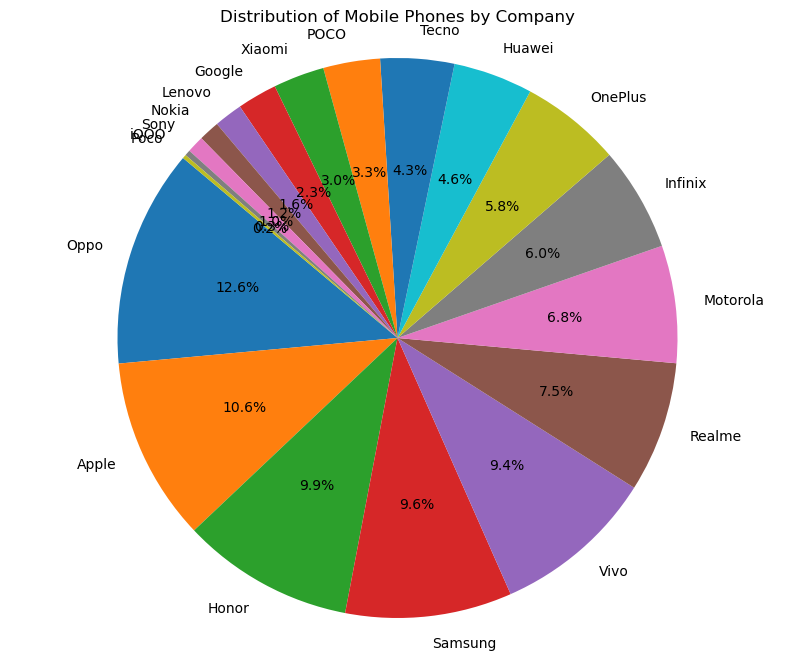

In [17]:
# TODO: Visualize the pie chart showing the distribution of Company Name
company_counts = df['Company Name'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(company_counts, labels=company_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Mobile Phones by Company')
plt.axis('equal')
plt.show()

- What is your insights about above pie chart?

---

### Insights from the Pie Chart: *Distribution of Mobile Phones by Company*

* **Oppo dominates the dataset**, accounting for approximately **12.6%** of all mobile phone models. This suggests Oppo has a wide and diverse product lineup in the dataset.

* **Apple (10.6%)**, **Honor (9.9%)**, and **Samsung (9.6%)** follow closely behind, indicating that these brands are also strongly represented. Together, these four brands make up **over 40%** of the total dataset.

* **Vivo (9.4%)** and **Realme (7.5%)** show a significant presence, reflecting their aggressive expansion in mid-range and budget smartphone segments.

* **Motorola (6.8%)**, **Infinix (6.0%)**, and **OnePlus (5.8%)** contribute moderately, suggesting a balanced but smaller product range compared to top brands.

* Brands such as **Huawei (4.6%)**, **Tecno (4.3%)**, **POCO (3.3%)**, and **Xiaomi (3.0%)** have a noticeable yet limited share, possibly indicating either fewer models released or selective inclusion in the dataset.

* **Niche or legacy brands** like **Google, Lenovo, Nokia, Sony, and iQOO** together represent a **very small fraction** of the dataset (each under 2%), highlighting lower model diversity or limited market focus in this data.

---

### Overall Observation

The dataset is **skewed toward manufacturers with broad product portfolios**, especially brands targeting multiple market segments (budget to flagship). This imbalance should be considered in further analysis or modeling, as dominant brands may disproportionately influence trends and predictions.

---


#### 3.4.2. Bar chart:

Comparison of Launched Prices (USD) across iPhone 16 Models.

*You can create a different visualization that looks better than the sample visualization provided below.*

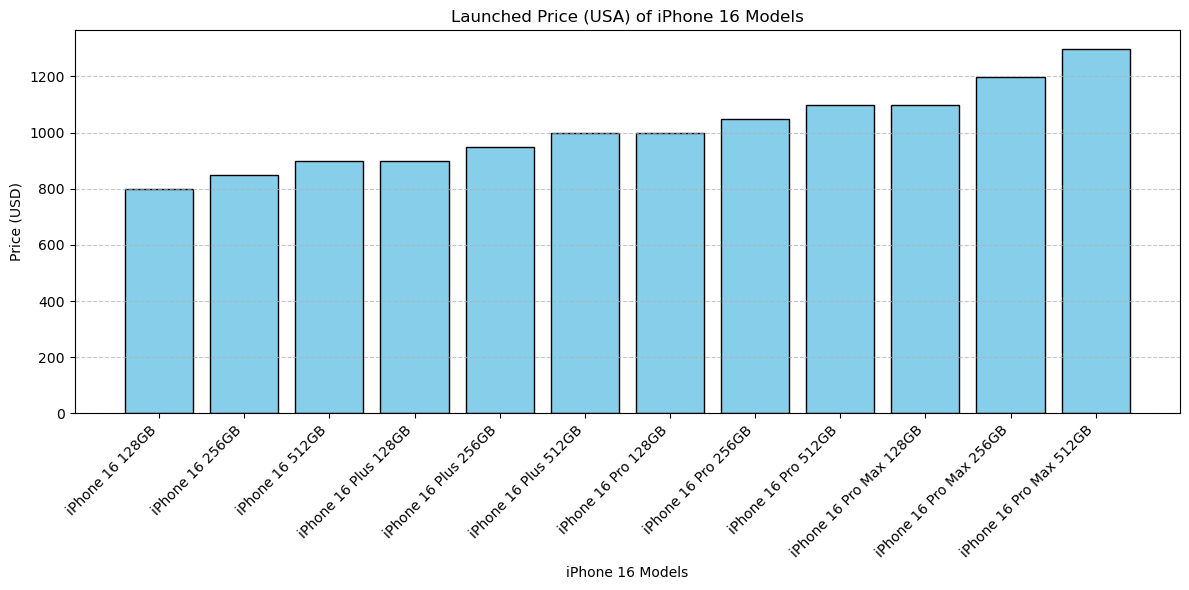

In [18]:
# TODO: Visualize the bar chart showing Launched Price (USA) (USD) for different iPhone 16 Models

# Filter for iPhone 16 models (assuming 'Apple' is the company, searching Model Name)
iphone_16_df = df[df['Model Name'].str.contains('iPhone 16')].sort_values('Launched Price (USA) (USD)')

plt.figure(figsize=(12, 6))
plt.bar(iphone_16_df['Model Name'], iphone_16_df['Launched Price (USA) (USD)'], color='skyblue', edgecolor='black')
plt.xlabel('iPhone 16 Models')
plt.ylabel('Price (USD)')
plt.title('Launched Price (USA) of iPhone 16 Models')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- What is your insights about above visualization?

---

### Insights from the Bar Chart: *Launched Price (USA) of iPhone 16 Models*

*   **Clear Price Segmentation:** The chart illustrates a well-defined price ladder ranging from **\$799 (Base model)** to **~\$1,299 (Pro Max 512GB)**. Apple covers almost every \$100 price increment, ensuring there are no significant gaps in their pricing structure.

*   **Impact of Storage on Price:** Within each specific model family (Base, Plus, Pro, Pro Max), price increases are driven purely by storage capacity. This confirms that storage upgrades are a primary revenue driver for the company.

*   **Pricing Overlap Strategy:** There is a notable pricing overlap between the **high-end versions of lower-tier models** (e.g., iPhone 16 Plus 512GB) and the **entry-level versions of premium models** (e.g., iPhone 16 Pro 128GB). This forces consumers to face a trade-off: choose **more storage** or **better hardware features** (Pro Display/Camera) for roughly the same price.

*   **The "Pro" Premium:** The "Pro" and "Pro Max" series consistently command the highest prices, clearly separating them as luxury devices compared to the standard iPhone 16.

---

### Overall Observation

Apple utilizes a **granular tiered pricing strategy** designed to capture different segments of the high-end market. By creating overlaps between storage tiers and model types, they encourage "upselling," where consumers are psychologically nudged to spend slightly more for the next tier of features or capacity.

---

#### 3.4.3. Histogram

Visualize screen size distribution using a histogram to show how models are segmented by display size.

*You can create a different visualization that looks better than the sample visualization provided below.*

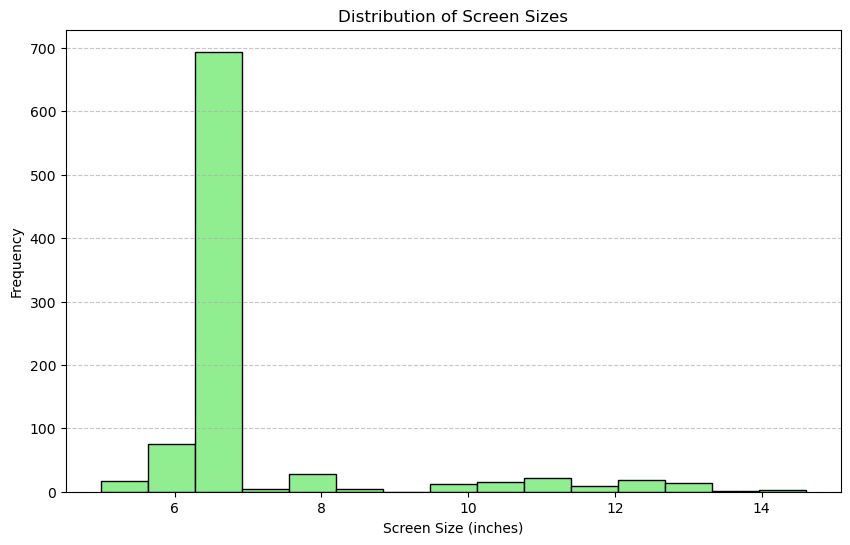

In [19]:
# TODO: Visualize screen size distribution using histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Screen Size (inches)'], bins=15, color='lightgreen', edgecolor='black')
plt.xlabel('Screen Size (inches)')
plt.ylabel('Frequency')
plt.title('Distribution of Screen Sizes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- What is your insights about above visualization?

---

### Insights from the Histogram: *Distribution of Screen Sizes*

* The distribution is **heavily concentrated between 6.0 and 6.7 inches**, indicating that this range is the **industry standard** for smartphones.

* **6.5–6.7 inches appears as the dominant peak**, suggesting manufacturers strongly favor large displays while maintaining one-hand usability.

* Screen sizes **below 6 inches are relatively rare**, reflecting a declining market for compact smartphones.

* A **long right tail (8–14+ inches)** is present, representing **foldable and tablet-like devices** (e.g., unfolded screens or dual-screen designs).

* The distribution is **right-skewed**, showing that while most phones cluster around similar sizes, a small number of models push toward much larger form factors.

---

### Overall Observation

The visualization highlights a clear market preference for **large smartphones**, with foldable devices emerging as a niche but growing segment that expands screen size boundaries without dominating the market.

---

#### 3.4.4. Other Visualization

**TODO**: Briefly describe your visualization here.

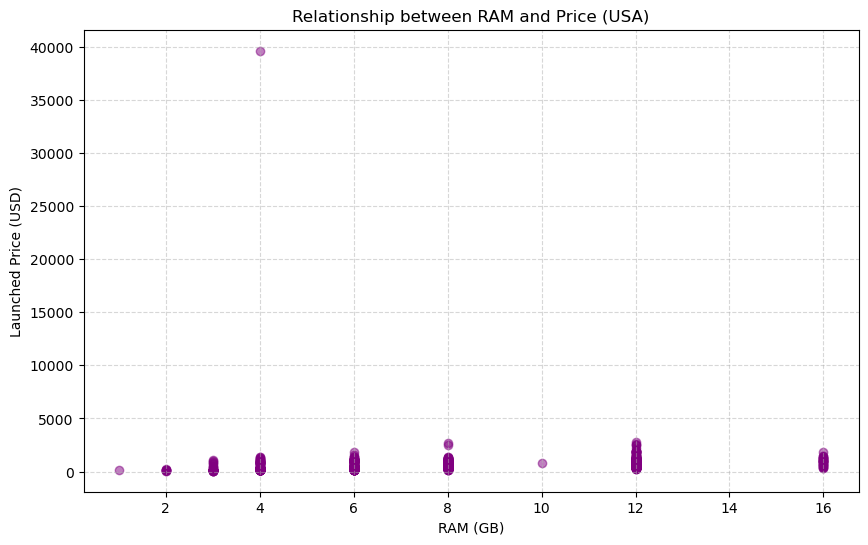

In [20]:
# TODO: Other visualizations

# Scatter plot to see relationship between RAM and USA Price
plt.figure(figsize=(10, 6))
plt.scatter(df['RAM (GB)'], df['Launched Price (USA) (USD)'], alpha=0.5, c='purple')
plt.xlabel('RAM (GB)')
plt.ylabel('Launched Price (USD)')
plt.title('Relationship between RAM and Price (USA)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- What is your insights about above visualization?

---

### Insights from the Scatter Plot: *Relationship between RAM and Price (USA)*

* There is a **general positive relationship** between RAM and price: phones with **higher RAM (8–16GB)** tend to be priced higher than those with **lower RAM (2–4GB)**.

* However, the relationship is **not strictly linear**. For the same RAM level (e.g. 8GB or 12GB), prices vary widely, indicating that **RAM alone does not determine price**.

* The **largest price dispersion** appears in the **8GB and 12GB RAM segments**, suggesting these are popular configurations across **both mid-range and flagship devices**.

* Several **extreme outliers** exist (e.g. a device around **4GB RAM priced extremely high**), which likely correspond to **luxury phones, foldables, or data quality anomalies**. These points significantly skew the scale.

* Low-RAM devices (2–3GB) are **consistently low-priced**, showing clear segmentation at the budget end.

---

### Overall Interpretation

RAM contributes to pricing, but **brand, chipset, camera system, display technology, and form factor (e.g. foldables)** play a much larger role in defining a phone’s final price. This visualization highlights why **multivariate analysis** is necessary instead of relying on a single hardware feature.

---

## 4. Question proposing & Answering

- In this section, you are going to answer my 2 questions and propose 1 question. Note that these questions can all be answered by analyzing data. Theoretically, the proposed question have to benefit at a certain level. But this is exercise about `Pandas`, my questions can be aimed more at technical side than the meaningful side. But your question has to be meaningful :v

### 4.1. Memory Upgrade

What is the average percentage increase in price when upgrading the memory from 4GB to 8GB?

In [21]:
# TODO: Answer the question

# We use MEDIAN instead of MEAN because the dataset contains outliers.
# (e.g., Premium phones with low RAM vs. Budget phones with high RAM)

median_price_4gb = df[df['RAM (GB)'] == 4]['Launched Price (USA) (USD)'].median()
median_price_8gb = df[df['RAM (GB)'] == 8]['Launched Price (USA) (USD)'].median()

if pd.notna(median_price_4gb) and pd.notna(median_price_8gb) and median_price_4gb != 0:
    percentage_change = ((median_price_8gb - median_price_4gb) / median_price_4gb) * 100
    
    print(f"Median Price 4GB: ${median_price_4gb:.2f}")
    print(f"Median Price 8GB: ${median_price_8gb:.2f}")
    
    if percentage_change > 0:
        print(f"Percentage increase in price: +{percentage_change:.2f}%")
    else:
        print(f"Percentage difference: {percentage_change:.2f}%")
        print("(Note: The negative value suggests market segmentation differences rather than direct upgrade costs.)")
else:
    print("Insufficient data.")

Median Price 4GB: $200.00
Median Price 8GB: $499.00
Percentage increase in price: +149.50%


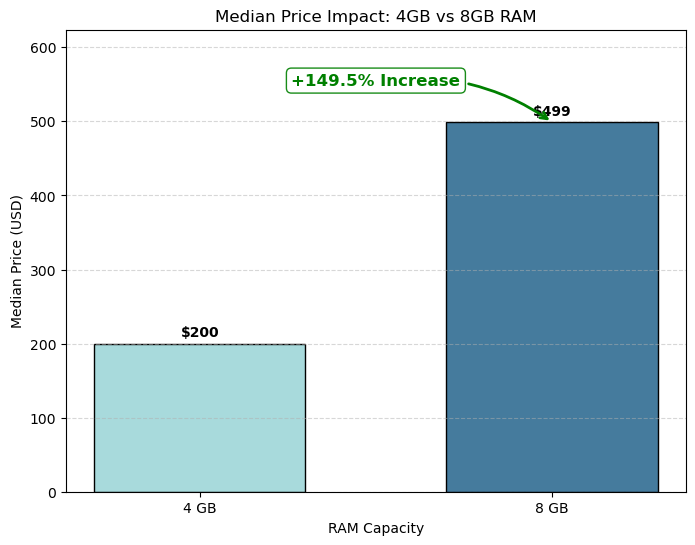

In [22]:
# TODO (OPTIONAL): Visualize

# 1. Prepare Data using MEDIAN (to match your analysis)
ram_comparison = df[df['RAM (GB)'].isin([4, 8])].groupby('RAM (GB)')['Launched Price (USA) (USD)'].median()

if len(ram_comparison) == 2:
    # 2. Setup Plot
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        ram_comparison.index.astype(str) + ' GB', 
        ram_comparison.values, 
        color=['#a8dadc', '#457b9d'], 
        edgecolor='black', 
        width=0.6
    )

    # 3. Add Price Labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2., 
            height + 5, 
            f'${height:.0f}', 
            ha='center', va='bottom', fontweight='bold'
        )

    # 4. Annotate Percentage Change
    price_4gb = ram_comparison[4]
    price_8gb = ram_comparison[8]
    pct_change = ((price_8gb - price_4gb) / price_4gb) * 100
    
    # Determine label text (Increase vs Decrease)
    if pct_change >= 0:
        change_text = f'+{pct_change:.1f}% Increase'
        arrow_color = 'green'
    else:
        change_text = f'{pct_change:.1f}% Difference' # or "Decrease"
        arrow_color = 'red'

    # Draw an arrow from the top of 4GB bar towards the top of 8GB bar
    # We adjust the text position slightly based on whether it is going up or down
    plt.annotate(
        change_text,
        xy=(1, price_8gb), 
        xytext=(0.5, max(price_4gb, price_8gb) + 50), # Place text higher up
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.2', color=arrow_color, lw=2),
        fontsize=12, color=arrow_color, fontweight='bold', ha='center',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=arrow_color, alpha=0.9)
    )

    # 5. Labels and Titles
    plt.xlabel('RAM Capacity')
    plt.ylabel('Median Price (USD)') # Updated Label
    plt.title('Median Price Impact: 4GB vs 8GB RAM') # Updated Title
    plt.ylim(0, max(ram_comparison.values) * 1.25) # Increase headroom for the arrow
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.show()
else:
    print("Insufficient data (missing 4GB or 8GB models) to create visualization.")

### Insights: Price Impact of Upgrading RAM (4GB vs. 8GB)

*   **Distinct Market Segmentation:** The massive **149.5% price gap** confirms a clear separation in the market.
    *   **4GB RAM (\$200)** represents the **Entry-Level / Budget** segment, aimed at basic users.
    *   **8GB RAM (\$499)** represents the **Mid-Range to Premium** standard. In 2025, 8GB is likely the minimum requirement for a "smooth" experience, and manufacturers price these devices significantly higher.

*   **Proxy for Overall Quality:** The \$299 price difference cannot be explained by the cost of the RAM chips alone (which is relatively low). Instead, RAM capacity acts as a **proxy for overall device quality**. A phone with 8GB RAM typically comes with a faster processor, better display, and superior cameras compared to a 4GB model.

*   **The "Mid-Range Tax":** Consumers face a steep "upgrade tax." To move from a basic functional phone (4GB) to a performant daily driver (8GB), they must essentially **multiply their budget by 2.5 times**. There is no linear progression; it is a step-change in pricing.

*   **Effectiveness of Median:** Using the **Median** successfully filtered out outliers. Unlike the Mean (which might have been skewed by old luxury phones with low RAM), the Median correctly reflects the "typical" price a consumer sees on the shelf today: \$200 for a budget phone and \$500 for a solid mid-range device.

---

### 4.2. Relationship Between Device Weight and Battery Capacity

Is there any relationship between device weight and battery capacity?

In [23]:
# TODO: Answer the question

# Calculate correlation coefficient
correlation = df['Mobile Weight (g)'].corr(df['Battery Capacity (mAh)'])

print(f"Correlation coefficient between Weight and Battery Capacity: {correlation:.4f}")

if correlation > 0.5:
    print("There is a strong positive relationship: Heavier phones tend to have larger batteries.")
elif correlation > 0.3:
    print("There is a moderate positive relationship.")
else:
    print("The relationship is weak.")

Correlation coefficient between Weight and Battery Capacity: 0.8480
There is a strong positive relationship: Heavier phones tend to have larger batteries.


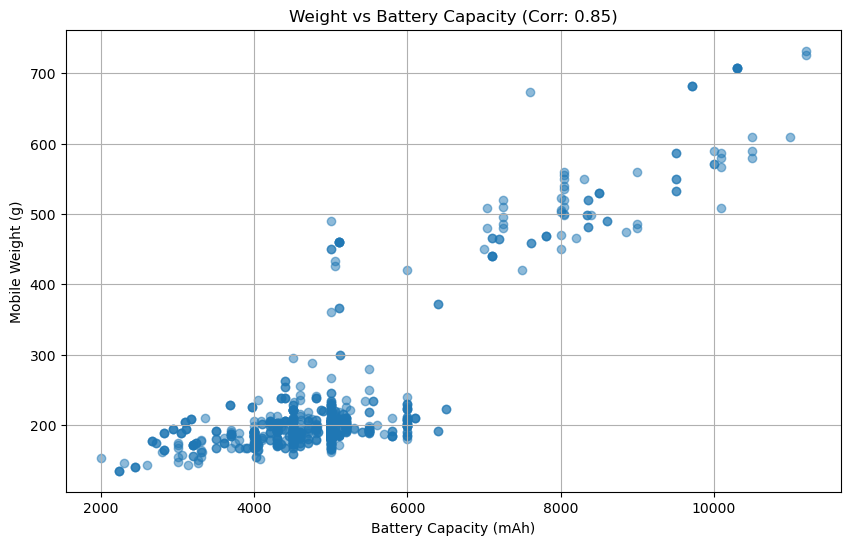

In [24]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(10, 6))
plt.scatter(df['Battery Capacity (mAh)'], df['Mobile Weight (g)'], alpha=0.5)
plt.xlabel('Battery Capacity (mAh)')
plt.ylabel('Mobile Weight (g)')
plt.title(f'Weight vs Battery Capacity (Corr: {correlation:.2f})')
plt.grid(True)
plt.show()

### 4.3. Which Company offers the most affordable average Launch Price in the USA?

In [25]:
# TODO: Answer the question

# Group by Company and calculate mean price
avg_price_by_company = df.groupby('Company Name')['Launched Price (USA) (USD)'].mean().sort_values()

# Get the cheapest
cheapest_company = avg_price_by_company.index[0]
cheapest_price = avg_price_by_company.iloc[0]

print(f"The company with the lowest average launch price in the USA is {cheapest_company} at ${cheapest_price:.2f}")
print("\nTop 5 most affordable brands (Avg Price):")
print(avg_price_by_company.head(5))

The company with the lowest average launch price in the USA is Infinix at $247.55

Top 5 most affordable brands (Avg Price):
Company Name
Infinix    247.545455
Realme     273.333333
Poco       290.000000
POCO       309.666667
Lenovo     311.666667
Name: Launched Price (USA) (USD), dtype: float64


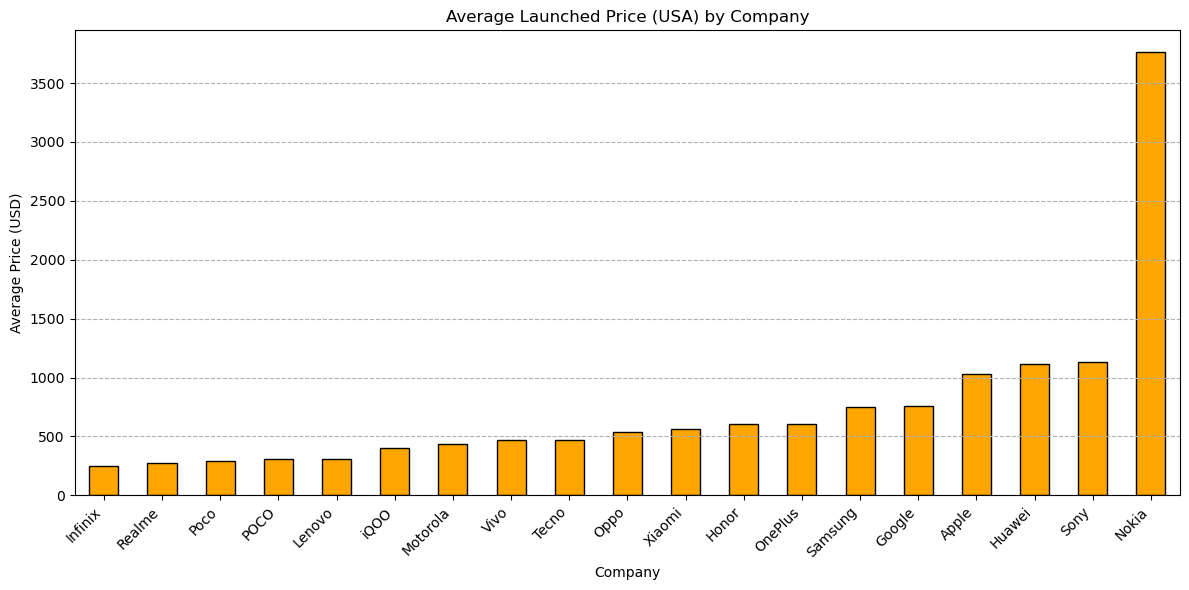

In [26]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(12, 6))
avg_price_by_company.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Company')
plt.ylabel('Average Price (USD)')
plt.title('Average Launched Price (USA) by Company')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**TODO**

Your insights for your proposed question:

### Insights: Most Affordable Average Launch Price (USA)

* **Infinix** stands out as the **most affordable brand** in the U.S. market, with an average launch price of **~$247.55**, positioning it clearly in the **budget smartphone segment**.

* The **top 5 most affordable brands** (Infinix, Realme, Poco/POCO, Lenovo) are all known for targeting **price-sensitive consumers**, offering competitive specifications at lower prices compared to premium brands.

* **Poco vs POCO** appearing separately suggests a **data consistency issue** (brand name casing), which slightly affects ranking and should ideally be standardized for more accurate aggregation.

* Brands in this group generally **prioritize value over premium features**, making them attractive in **emerging markets and entry-level U.S. segments**.

* In contrast, premium-oriented brands (e.g. Apple, Samsung, Google, Sony) have significantly higher average launch prices, highlighting a **clear market segmentation** between budget and flagship-focused companies.

---

### Overall Interpretation

The U.S. smartphone market shows a strong **price-based segmentation**, where brands like **Infinix and Realme dominate affordability**, while others compete on ecosystem, brand value, and high-end innovation rather than price.

If you want, I can:

* Rewrite this in **1–2 concise sentences for a report**
* Add **business or market strategy insights**
* Help **clean brand names** (POCO vs Poco) and re-run the analysis

---


Well done!